In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import yaml

from pmt_analysis import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Read Data

In [2]:
file_name = 'WA0089_850V_20MHz_Cold_led1'


data_dir = Path("data/calibLED/260615")
# files = sorted(data_dir.glob(f"{file_name}-1.h5")) 
files = sorted(data_dir.glob(f"{file_name}-*.h5")) 

config_name = file_name

led_name = config_name.split('_')[-1]

for file in files:
    print(file)
print(f"Number of files: {len(files)}")

data/calibLED/260615/WA0089_850V_20MHz_Cold_led1-1.h5
data/calibLED/260615/WA0089_850V_20MHz_Cold_led1-10.h5
data/calibLED/260615/WA0089_850V_20MHz_Cold_led1-2.h5
data/calibLED/260615/WA0089_850V_20MHz_Cold_led1-3.h5
data/calibLED/260615/WA0089_850V_20MHz_Cold_led1-4.h5
data/calibLED/260615/WA0089_850V_20MHz_Cold_led1-5.h5
data/calibLED/260615/WA0089_850V_20MHz_Cold_led1-6.h5
data/calibLED/260615/WA0089_850V_20MHz_Cold_led1-7.h5
data/calibLED/260615/WA0089_850V_20MHz_Cold_led1-8.h5
data/calibLED/260615/WA0089_850V_20MHz_Cold_led1-9.h5
Number of files: 10


In [3]:
maxEvts = 1000 # small sample size
time_s, voltage_sample_V, metadata = read_keysight_h5_direct(
    files[0],
    segment_numbers=range(maxEvts),
)
time_ns, voltage_sample_mV, adc_step_mV, units_time, units_voltage = standard_units(
    time_s,
    voltage_sample_V,
    metadata,
)

print(f"Sample waveforms: {voltage_sample_mV.shape}")
print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV")

Sample waveforms: (999, 1601)
Time range: -0.029 to 99.971 ns
Sampling step: 0.06250 ns
ADC step: 0.000214 mV


# Set Config. Values

In [4]:
# default config
with open('config_default.yml', 'r') as file:
    # Load and parse the YAML content safely
    config = yaml.safe_load(file)[config_name]['general']

## config
baseline_window_ns     = (time_ns[0], time_ns[0]+config['baseline_window_width_ns'])
integration_window_ns  = (config['integration_window_ns'][0], config['integration_window_ns'][1])
peak_search_window_ns  = (config['peak_search_window_ns'][0], config['peak_search_window_ns'][1])
allowed_peak_window_ns = (config['allowed_peak_window_ns'][0], config['allowed_peak_window_ns'][1])
global_peak_voltage_max_mV = None if (config['global_peak_voltage_max_mV']=='None') else (config['global_peak_voltage_max_mV'])
out_of_window_peak_voltage_max_mV = config['out_of_window_peak_voltage_max_mV']

config



{'baseline_window_width_ns': 20,
 'integration_window_ns': [30, 80],
 'peak_search_window_ns': [30, 80],
 'global_peak_voltage_max_mV': 'None',
 'out_of_window_peak_voltage_max_mV': -1.0,
 'allowed_peak_window_ns': [30, 40]}

In [5]:
### not in config
# threshold_for_mean_mV = 0. # threshold to compute mean waveform (if no cut, the baseline dominates)
threshold_for_mean_mV = out_of_window_peak_voltage_max_mV # threshold to compute mean waveform (if no cut, the baseline dominates)
rise_low_fraction = 0.1
rise_high_fraction = 0.9
show_residual_errorbars = True



# Baseline Subtraction

In [6]:
voltage_sample_bs_mV, sample_baseline_mV = subtract_baseline(
    time_ns,
    voltage_sample_mV,
    baseline_window_ns=baseline_window_ns,
)

In [ ]:
# Compute the peak selection early so the mean waveform can be restricted to
# events with a real pulse. Baseline QA distributions below still use all events.
selection = collect_peak_time_voltage_selection(
    files,
    baseline_window_ns=baseline_window_ns,
    peak_window_ns=allowed_peak_window_ns,
    global_peak_voltage_max_mV=global_peak_voltage_max_mV,
    out_of_window_peak_voltage_max_mV=out_of_window_peak_voltage_max_mV,
    peak_search_window_ns=peak_search_window_ns,
    selection_mask=None,
    chunk_size=4096,
    low_fraction=rise_low_fraction,
    high_fraction=rise_high_fraction,
)

real_peak_mask = selection["real_peak_mask"]
in_peak_window_mask = selection["in_peak_window_mask"]
keep_mask = selection["keep_mask"]
real_in_time_mask = real_peak_mask & in_peak_window_mask
real_out_of_time_mask = real_peak_mask & ~in_peak_window_mask
real_peak_threshold_amplitude_mV = (
    abs(out_of_window_peak_voltage_max_mV) if out_of_window_peak_voltage_max_mV is not None else None
)

summary_all = summarize_waveforms(
    files,
    baseline_window_ns=baseline_window_ns,
    chunk_size=4096,
    selection_mask=None,
)

summary_real_peak = None
if np.any(real_peak_mask):
    summary_real_peak = summarize_waveforms(
        files,
        baseline_window_ns=baseline_window_ns,
        chunk_size=4096,
        selection_mask=real_peak_mask,
    )

# Keep the old name for downstream cells that use baseline QA quantities.
summary = summary_all

# The displayed mean waveform should not be diluted by pedestal-only events.
summary_mean = summary_real_peak if summary_real_peak is not None else summary_all
mean_waveform_label = "real-peak events" if summary_real_peak is not None else "all events (no real peaks found)"
mean_waveform = summary_mean["mean_waveform_mV"]
std_waveform = summary_mean["std_waveform_mV"]
idx_min = int(np.argmin(mean_waveform))
baseline_values = summary_all["baseline_mV"]
baseline_residuals = summary_all["baseline_check_mV"]


def describe_values(values, unit=""):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return "no finite entries"
    q05, q50, q95 = np.quantile(values, [0.05, 0.50, 0.95])
    suffix = f" {unit}" if unit else ""
    return (
        f"mean={np.mean(values):.4g}{suffix}, std={np.std(values):.4g}{suffix}, "
        f"median={q50:.4g}{suffix}, 5-95%=[{q05:.4g}, {q95:.4g}]{suffix}"
    )

print(f"Data set: {led_name}")
print(f"Files: {len(files)}")
print(f"Processed events for baseline QA: {summary_all['n_events']:,}")
print(f"Events used for displayed mean waveform: {summary_mean['n_events']:,} ({mean_waveform_label})")
print(f"Baseline window: {baseline_window_ns[0]:.2f} to {baseline_window_ns[1]:.2f} ns")
print(f"Integration window: {integration_window_ns[0]:.2f} to {integration_window_ns[1]:.2f} ns")
print(f"Allowed peak window: {allowed_peak_window_ns[0]:.2f} to {allowed_peak_window_ns[1]:.2f} ns")
print()
print("Baseline before subtraction, all events:")
print("  " + describe_values(baseline_values, "mV"))
print("Residual mean inside baseline window after subtraction, all events:")
print("  " + describe_values(baseline_residuals, "mV"))
print()
print(
    f"Mean waveform minimum ({mean_waveform_label}): "
    f"t={summary_mean['time_ns'][idx_min]:.3f} ns, "
    f"V={mean_waveform[idx_min]:.4f} mV, "
    f"RMS at that time={std_waveform[idx_min]:.4f} mV"
)


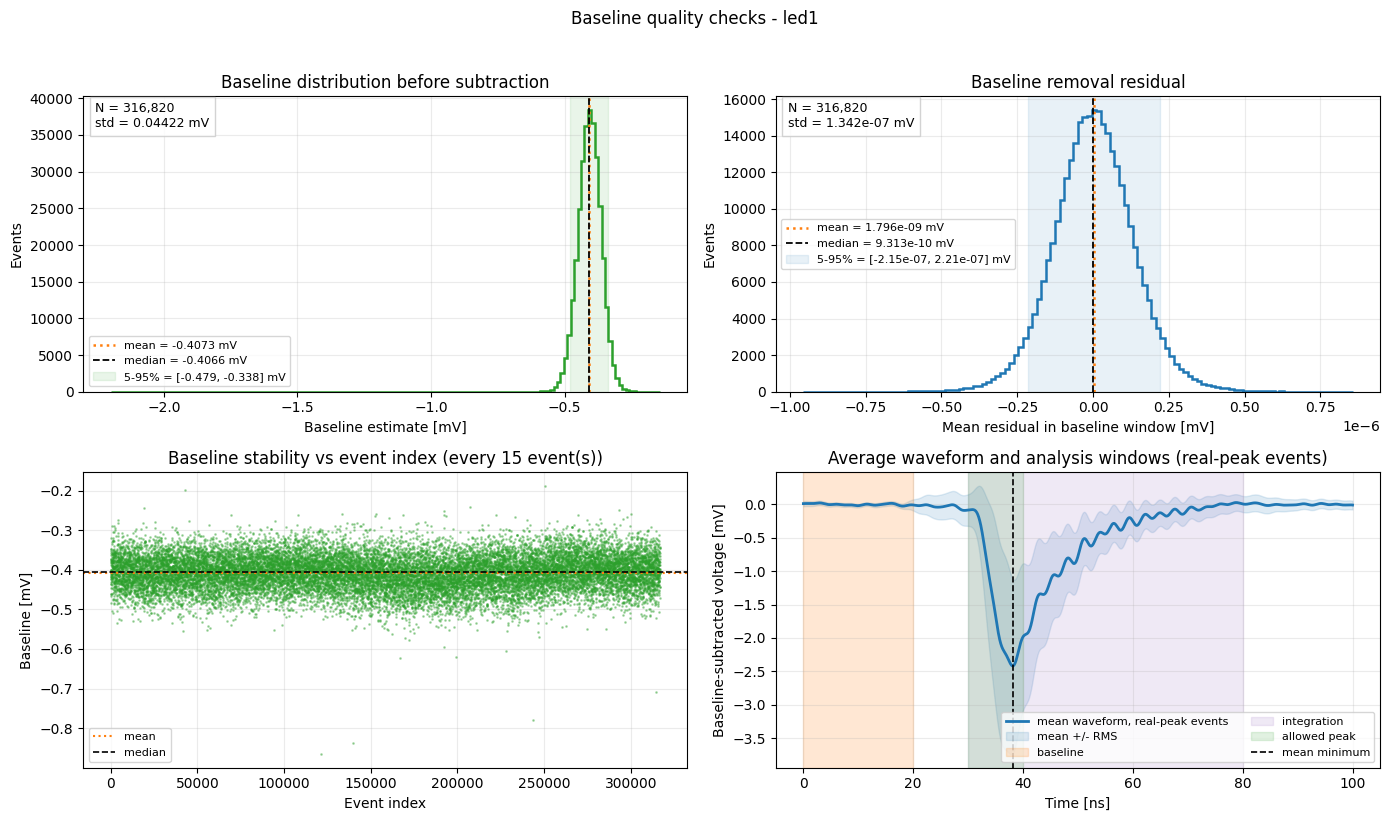

In [ ]:
def add_hist_stats(ax, values, bins, color, xlabel, title, unit=""):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    ax.hist(values, bins=bins, histtype="step", lw=1.8, color=color)
    if len(values):
        mean = np.mean(values)
        median = np.median(values)
        std = np.std(values)
        q05, q95 = np.quantile(values, [0.05, 0.95])
        label_unit = f" {unit}" if unit else ""
        ax.axvline(mean, color="tab:orange", ls=":", lw=1.8, label=f"mean = {mean:.4g}{label_unit}")
        ax.axvline(median, color="black", ls="--", lw=1.3, label=f"median = {median:.4g}{label_unit}")
        ax.axvspan(q05, q95, color=color, alpha=0.10, label=f"5-95% = [{q05:.3g}, {q95:.3g}]{label_unit}")
        ax.text(
            0.02,
            0.98,
            f"N = {len(values):,}\nstd = {std:.4g}{label_unit}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.85),
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Events")
    ax.set_title(title)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

add_hist_stats(
    axes[0],
    baseline_values,
    bins=160,
    color="tab:green",
    xlabel="Baseline estimate [mV]",
    title="Baseline distribution before subtraction",
    unit="mV",
)

add_hist_stats(
    axes[1],
    baseline_residuals,
    bins=120,
    color="tab:blue",
    xlabel="Mean residual in baseline window [mV]",
    title="Baseline removal residual",
    unit="mV",
)

max_points = 20000
step = max(1, len(baseline_values) // max_points)
event_index = np.arange(len(baseline_values))[::step]
axes[2].plot(event_index, baseline_values[::step], ".", ms=2, alpha=0.35, color="tab:green")
axes[2].axhline(np.mean(baseline_values), color="tab:orange", ls=":", lw=1.5, label="mean")
axes[2].axhline(np.median(baseline_values), color="black", ls="--", lw=1.2, label="median")
axes[2].set_xlabel("Event index")
axes[2].set_ylabel("Baseline [mV]")
axes[2].set_title(f"Baseline stability vs event index (every {step} event(s))")
axes[2].legend(fontsize=8)

axes[3].plot(summary_mean["time_ns"], mean_waveform, color="tab:blue", lw=2, label=f"mean waveform, {mean_waveform_label}")
axes[3].fill_between(
    summary_mean["time_ns"],
    mean_waveform - std_waveform,
    mean_waveform + std_waveform,
    color="tab:blue",
    alpha=0.14,
    label="mean +/- RMS",
)
axes[3].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.18, label="baseline")
axes[3].axvspan(*integration_window_ns, color="tab:purple", alpha=0.14, label="integration")
axes[3].axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.14, label="allowed peak")
axes[3].axvline(summary_mean["time_ns"][idx_min], color="black", ls="--", lw=1.2, label="mean minimum")
axes[3].set_xlabel("Time [ns]")
axes[3].set_ylabel("Baseline-subtracted voltage [mV]")
axes[3].set_title(f"Average waveform and analysis windows ({mean_waveform_label})")
axes[3].legend(fontsize=8, ncol=2)

fig.suptitle(f"Baseline quality checks - {led_name}", y=1.02)
fig.tight_layout()


## Look at a small data sample

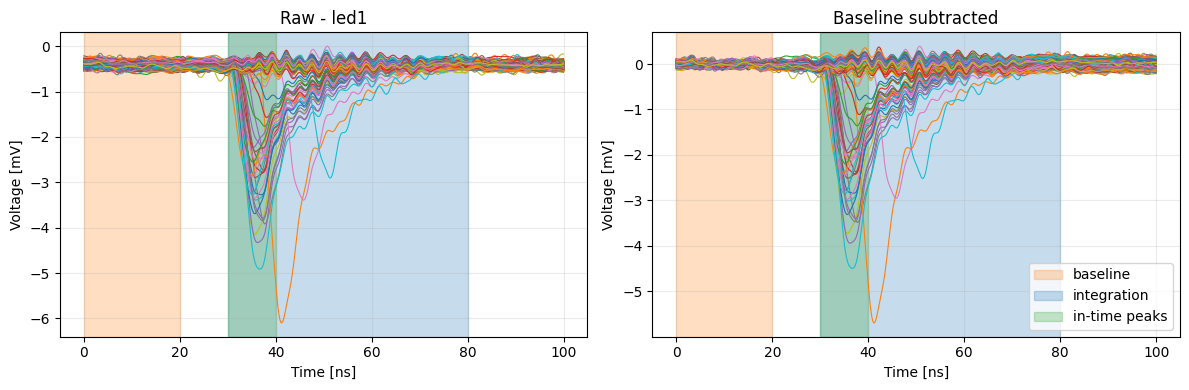

In [ ]:
show_wfs = True

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for waveform in voltage_sample_mV[:maxEvts]:
    if show_wfs:
        axes[0].plot(time_ns, waveform, lw=0.8)
    else:
        axes[0].plot(time_ns, waveform, color="0.45", alpha=0.12, lw=0.8)
for waveform in voltage_sample_bs_mV[:maxEvts]:
    if show_wfs:
        axes[1].plot(time_ns, waveform, lw=0.8)
    else:
        axes[1].plot(time_ns, waveform, color="tab:blue", alpha=0.12, lw=0.8)

for ax in axes:
    ax.axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    ax.axvspan(*integration_window_ns, color="tab:blue", alpha=0.25, label="integration")
    ax.axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.25, label="in-time peaks")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Voltage [mV]")
axes[0].set_title(f"Raw - {led_name}")
axes[1].set_title("Baseline subtracted")
axes[1].legend(loc="lower right")
fig.tight_layout()

# Selection

- remove peaks that are clearely out of time (+ small threshold to define "a peak")

In [ ]:
if "selection" not in globals():
    selection = collect_peak_time_voltage_selection(
        files,
        baseline_window_ns=baseline_window_ns,
        peak_window_ns=allowed_peak_window_ns,
        global_peak_voltage_max_mV=global_peak_voltage_max_mV,
        out_of_window_peak_voltage_max_mV=out_of_window_peak_voltage_max_mV,
        peak_search_window_ns=peak_search_window_ns,
        selection_mask=None,
        chunk_size=4096,
        low_fraction=rise_low_fraction,
        high_fraction=rise_high_fraction,
    )

real_peak_mask = selection["real_peak_mask"]
in_peak_window_mask = selection["in_peak_window_mask"]
keep_mask = selection["keep_mask"]
real_in_time_mask = real_peak_mask & in_peak_window_mask
real_out_of_time_mask = real_peak_mask & ~in_peak_window_mask
real_peak_threshold_amplitude_mV = (
    abs(out_of_window_peak_voltage_max_mV) if out_of_window_peak_voltage_max_mV is not None else None
)


def print_count_row(label, n, total):
    frac = 100.0 * n / total if total else np.nan
    print(f"{label:<44} {n:>10,} / {total:<10,} ({frac:7.3f}%)")

print(f"Selection summary - {led_name}")
print("=" * 78)
print(f"Peak search window:        {peak_search_window_ns[0]:.2f} to {peak_search_window_ns[1]:.2f} ns")
print(f"Allowed peak window:       {allowed_peak_window_ns[0]:.2f} to {allowed_peak_window_ns[1]:.2f} ns")
print(f"Global peak-voltage cut:   {global_peak_voltage_max_mV}")
print(f"Out-of-window veto cut:    {out_of_window_peak_voltage_max_mV:.4g} mV")
print(f"Rise-time fractions:       {rise_low_fraction:.0%} to {rise_high_fraction:.0%}")
print("-" * 78)
print_count_row("Events kept by final selection", selection["n_kept"], selection["n_total"])
print_count_row("Events with real peak anywhere", int(np.sum(real_peak_mask)), selection["n_total"])
print_count_row("Events with peak inside allowed window", int(np.sum(in_peak_window_mask)), selection["n_total"])
print_count_row("Real peaks inside allowed window", int(np.sum(real_in_time_mask)), selection["n_total"])
print_count_row("Real peaks vetoed outside window", int(np.sum(real_out_of_time_mask)), selection["n_total"])
print("=" * 78)


Selection summary - led1
Peak search window:        30.00 to 80.00 ns
Allowed peak window:       30.00 to 40.00 ns
Global peak-voltage cut:   None
Out-of-window veto cut:    -1 mV
Rise-time fractions:       10% to 90%
------------------------------------------------------------------------------
Events kept by final selection                  313,977 / 316,820    ( 99.103%)
Events with real peak anywhere                   13,094 / 316,820    (  4.133%)
Events with peak inside allowed window           43,796 / 316,820    ( 13.824%)
Real peaks inside allowed window                 10,251 / 316,820    (  3.236%)
Real peaks vetoed outside window                  2,843 / 316,820    (  0.897%)


In [ ]:
def print_quantiles(label, values, unit="", probs=(0.01, 0.05, 0.50, 0.95, 0.99)):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    suffix = f" {unit}" if unit else ""
    print(label)
    if len(values) == 0:
        print("  no finite entries")
        return
    qs = np.quantile(values, probs)
    for prob, value in zip(probs, qs):
        print(f"  q{prob:5.2%}: {value:10.4g}{suffix}")

print("Selection variable summary")
print("=" * 72)
print_quantiles("Peak time, all events", selection["peak_time_ns"], "ns")
print_quantiles("Peak amplitude, all events", selection["peak_amplitude_mV"], "mV")
print_quantiles("Peak time, real peaks", selection["peak_time_ns"][real_peak_mask], "ns")
print_quantiles("Peak amplitude, real peaks", selection["peak_amplitude_mV"][real_peak_mask], "mV")
print_quantiles(
    f"Rise time, valid real peaks ({rise_low_fraction:.0%}-{rise_high_fraction:.0%})",
    selection["rise_time_ns"][selection["rise_time_valid"] & real_peak_mask],
    "ns",
)
print("=" * 72)
print("Available selection fields:")
print(", ".join(selection.keys()))


Selection variable summary
Peak time, all events
  q1.00%:      30.01 ns
  q5.00%:      33.33 ns
  q50.00%:      49.45 ns
  q95.00%:      69.07 ns
  q99.00%:      72.01 ns
Peak amplitude, all events
  q1.00%:    0.03037 mV
  q5.00%:    0.06391 mV
  q50.00%:     0.1501 mV
  q95.00%:     0.3107 mV
  q99.00%:      3.862 mV
Peak time, real peaks
  q1.00%:      33.58 ns
  q5.00%:      35.26 ns
  q50.00%:      37.82 ns
  q95.00%:      44.38 ns
  q99.00%:      57.45 ns
Peak amplitude, real peaks
  q1.00%:      1.089 mV
  q5.00%:       1.39 mV
  q50.00%:      3.085 mV
  q95.00%:      5.029 mV
  q99.00%:      6.042 mV
Rise time, valid real peaks (10%-90%)
  q1.00%:      2.565 ns
  q5.00%:       2.71 ns
  q50.00%:      2.953 ns
  q95.00%:      3.652 ns
  q99.00%:      10.27 ns
Available selection fields:
keep_mask, n_total, n_kept, efficiency, real_peak_mask, in_peak_window_mask, peak_time_ns, peak_value_mV, peak_amplitude_mV, t_low_ns, t_high_ns, rise_time_ns, rise_time_valid, low_fraction, hig

## Display some stats. (small sample)

In [ ]:
sample_n = len(voltage_sample_bs_mV)
sample_timing = {
    key: selection[key][:sample_n]
    for key in [
        "peak_time_ns",
        "peak_value_mV",
        "peak_amplitude_mV",
        "t_low_ns",
        "t_high_ns",
        "rise_time_ns",
        "rise_time_valid",
        "real_peak_mask",
        "in_peak_window_mask",
        "keep_mask",
    ]
}

sample_selection_mask = sample_timing["keep_mask"]
sample_real_peak_mask = sample_timing["real_peak_mask"]
selected_sample_wfs = voltage_sample_bs_mV[sample_selection_mask]
selected_sample_mask = sample_selection_mask
selected_sample_peaks = {
    key: value[sample_selection_mask]
    for key, value in sample_timing.items()
    if isinstance(value, np.ndarray) and len(value) == sample_n
}

valid_rise_mask = sample_timing["rise_time_valid"] & sample_real_peak_mask

print(f"Sample timing summary ({sample_n:,} waveforms loaded in memory)")
print("=" * 76)
print_count_row("Sample events with real peaks", int(np.sum(sample_real_peak_mask)), sample_n)
print_count_row("Sample events kept by selection", int(np.sum(sample_selection_mask)), sample_n)
print_count_row("Sample real peaks in allowed window", int(np.sum(sample_real_peak_mask & sample_timing["in_peak_window_mask"])), sample_n)
print("-" * 76)
if np.any(sample_real_peak_mask):
    print_quantiles("Peak time for sample real peaks", sample_timing["peak_time_ns"][sample_real_peak_mask], "ns", probs=(0.05, 0.50, 0.95))
    print_quantiles("Peak amplitude for sample real peaks", sample_timing["peak_amplitude_mV"][sample_real_peak_mask], "mV", probs=(0.05, 0.50, 0.95))
else:
    print("No real peaks in the loaded sample.")
if np.any(valid_rise_mask):
    print_quantiles(
        f"Rise time for sample real peaks ({rise_low_fraction:.0%}-{rise_high_fraction:.0%})",
        sample_timing["rise_time_ns"][valid_rise_mask],
        "ns",
        probs=(0.05, 0.50, 0.95),
    )
else:
    print("No valid rise-time values in the loaded sample.")
print("=" * 76)


Sample timing summary (999 waveforms loaded in memory)
Sample events with real peaks                        30 / 999        (  3.003%)
Sample events kept by selection                     996 / 999        ( 99.700%)
Sample real peaks in allowed window                  27 / 999        (  2.703%)
----------------------------------------------------------------------------
Peak time for sample real peaks
  q5.00%:       35.1 ns
  q50.00%:      36.41 ns
  q95.00%:      43.73 ns
Peak amplitude for sample real peaks
  q5.00%:      1.599 mV
  q50.00%:      2.516 mV
  q95.00%:      4.246 mV
Rise time for sample real peaks (10%-90%)
  q5.00%:      2.712 ns
  q50.00%:      2.899 ns
  q95.00%:       3.71 ns


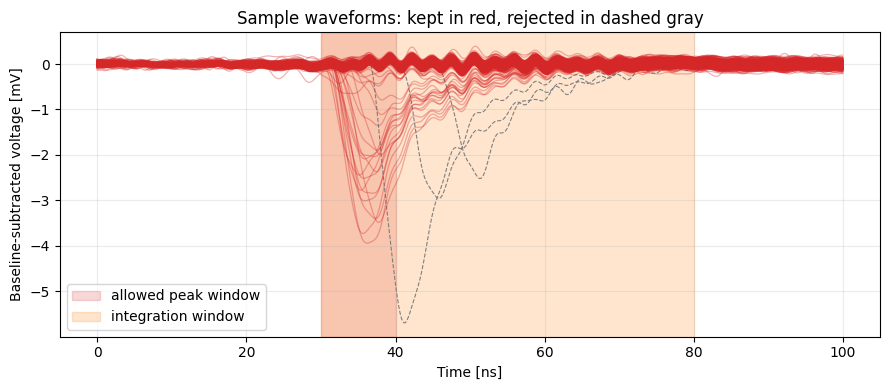

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
for waveform in voltage_sample_bs_mV[~sample_selection_mask][:500]:
    ax.plot(time_ns, waveform, color="tab:gray", lw=0.8, ls="--")
for waveform in selected_sample_wfs[:500]:
    ax.plot(time_ns, waveform, color="tab:red", alpha=0.35, lw=0.9)
ax.axvspan(*allowed_peak_window_ns, color="tab:red", alpha=0.18, label="allowed peak window")
ax.axvspan(*integration_window_ns, color="tab:orange", alpha=0.20, label="integration window")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Baseline-subtracted voltage [mV]")
ax.set_title("Sample waveforms: kept in red, rejected in dashed gray")
ax.legend()
fig.tight_layout()

/var/folders/80/x5l9nnmd2gb3szz23pnjrgpm0000gn/T/ipykernel_67085/313651986.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


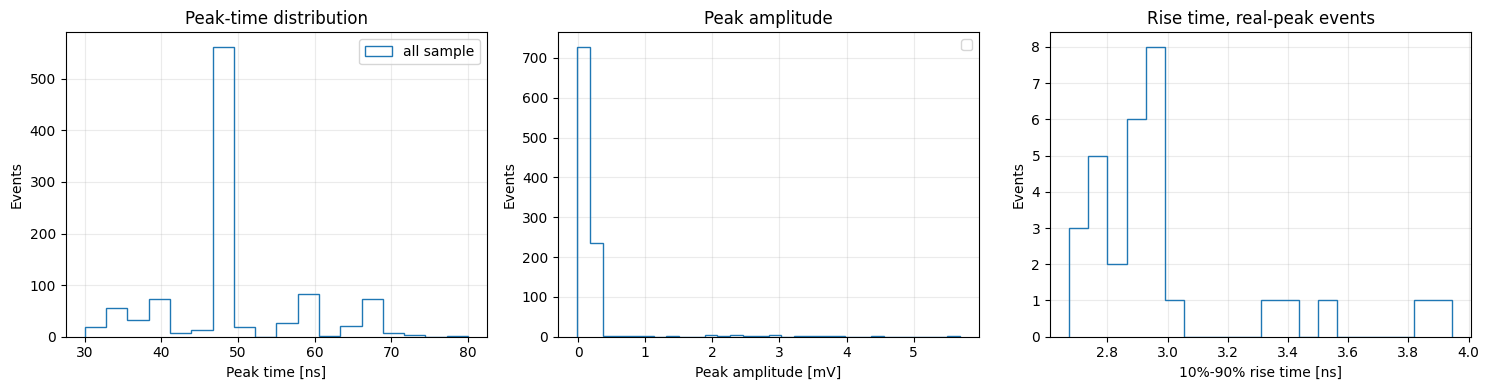

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(sample_timing["peak_time_ns"], bins=18, histtype="step", label="all sample")
# axes[0].hist(sample_timing["peak_time_ns"][sample_real_peak_mask], bins=80, histtype="step", label="real-peak")
# axes[0].axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.18, label="allowed peak window")
axes[0].set_xlabel("Peak time [ns]")
axes[0].set_ylabel("Events")
axes[0].set_title("Peak-time distribution")
axes[0].legend()

axes[1].hist(sample_timing["peak_amplitude_mV"], bins=30, range=None, histtype="step")
# axes[1].axvline(abs(out_of_window_peak_voltage_max_mV), color="tab:red", ls="--", label="real-peak threshold")
axes[1].set_xlabel("Peak amplitude [mV]")
axes[1].set_ylabel("Events")
axes[1].set_title("Peak amplitude")
# axes[1].set_yscale('log')
axes[1].legend()

axes[2].hist(sample_timing["rise_time_ns"][valid_rise_mask], bins=20, histtype="step")
axes[2].set_xlabel(f"{rise_low_fraction:.0%}-{rise_high_fraction:.0%} rise time [ns]")
axes[2].set_ylabel("Events")
axes[2].set_title("Rise time, real-peak events")
fig.tight_layout();

## Peak time vs peak amplitude

Use the full selection arrays to check whether earlier/later peaks also have systematically different amplitudes.


In [ ]:
def rankdata_average(values):
    values = np.asarray(values, dtype=float)
    order = np.argsort(values)
    ranks = np.empty(len(values), dtype=float)
    sorted_values = values[order]
    start = 0
    while start < len(values):
        stop = start + 1
        while stop < len(values) and sorted_values[stop] == sorted_values[start]:
            stop += 1
        ranks[order[start:stop]] = 0.5 * (start + stop - 1) + 1.0
        start = stop
    return ranks


def correlation_coefficients(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan
    pearson = np.corrcoef(x, y)[0, 1]
    spearman = np.corrcoef(rankdata_average(x), rankdata_average(y))[0, 1]
    return pearson, spearman

peak_time = selection["peak_time_ns"]
peak_amplitude = selection["peak_amplitude_mV"]
finite_peak = np.isfinite(peak_time) & np.isfinite(peak_amplitude)

correlation_masks = {
    "all finite events": finite_peak,
    "real peaks": finite_peak & real_peak_mask,
    "kept events": finite_peak & keep_mask,
    "real peaks in allowed window": finite_peak & real_in_time_mask,
}

print("Peak-time / peak-amplitude correlation")
print("=" * 104)
print(f"{'sample':<32} {'N':>10} {'time median [ns]':>18} {'amp median [mV]':>18} {'Pearson r':>12} {'Spearman rho':>14}")
print("-" * 104)
for label, mask in correlation_masks.items():
    n = int(np.sum(mask))
    if n:
        pearson, spearman = correlation_coefficients(peak_time[mask], peak_amplitude[mask])
        t_med = np.median(peak_time[mask])
        a_med = np.median(peak_amplitude[mask])
        print(f"{label:<32} {n:>10,} {t_med:>18.4g} {a_med:>18.4g} {pearson:>12.4f} {spearman:>14.4f}")
    else:
        print(f"{label:<32} {n:>10,} {'--':>18} {'--':>18} {'--':>12} {'--':>14}")
print("=" * 104)


Peak-time / peak-amplitude correlation
sample                                    N   time median [ns]    amp median [mV]    Pearson r   Spearman rho
--------------------------------------------------------------------------------------------------------
all finite events                   316,820              49.45             0.1501      -0.2297        -0.0036
real peaks                           13,094              37.82              3.085       0.0020         0.0083
kept events                         313,977              49.46             0.1495      -0.2276         0.0113
real peaks in allowed window         10,251              36.95              3.089       0.0535         0.0352


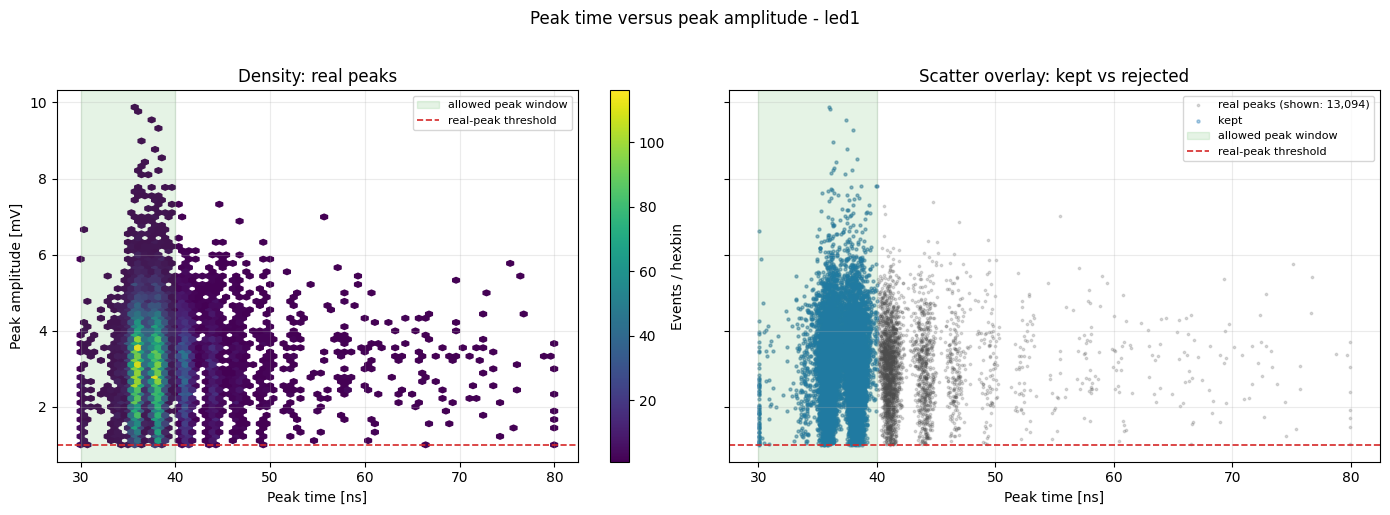

In [ ]:
plot_mask = finite_peak & real_peak_mask
max_plot_points = 150000
plot_indices = np.flatnonzero(plot_mask)
if len(plot_indices) > max_plot_points:
    rng = np.random.default_rng(12345)
    plot_indices = np.sort(rng.choice(plot_indices, size=max_plot_points, replace=False))

if len(plot_indices) == 0:
    print("No finite real-peak events available for the peak-time/amplitude plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    hb = axes[0].hexbin(
        peak_time[plot_mask],
        peak_amplitude[plot_mask],
        gridsize=70,
        mincnt=1,
        cmap="viridis",
    )
    axes[0].axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.12, label="allowed peak window")
    if real_peak_threshold_amplitude_mV is not None:
        axes[0].axhline(real_peak_threshold_amplitude_mV, color="tab:red", ls="--", lw=1.2, label="real-peak threshold")
    axes[0].set_xlabel("Peak time [ns]")
    axes[0].set_ylabel("Peak amplitude [mV]")
    axes[0].set_title("Density: real peaks")
    axes[0].legend(fontsize=8)
    fig.colorbar(hb, ax=axes[0], label="Events / hexbin")

    axes[1].scatter(
        peak_time[plot_indices],
        peak_amplitude[plot_indices],
        s=3,
        alpha=0.20,
        color="0.30",
        label=f"real peaks (shown: {len(plot_indices):,})",
    )
    kept_plot_indices = plot_indices[keep_mask[plot_indices]]
    axes[1].scatter(
        peak_time[kept_plot_indices],
        peak_amplitude[kept_plot_indices],
        s=5,
        alpha=0.35,
        color="tab:blue",
        label="kept",
    )
    axes[1].axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.12, label="allowed peak window")
    if real_peak_threshold_amplitude_mV is not None:
        axes[1].axhline(real_peak_threshold_amplitude_mV, color="tab:red", ls="--", lw=1.2, label="real-peak threshold")
    axes[1].set_xlabel("Peak time [ns]")
    axes[1].set_title("Scatter overlay: kept vs rejected")
    axes[1].legend(fontsize=8)

    fig.suptitle(f"Peak time versus peak amplitude - {led_name}", y=1.02)
    fig.tight_layout()


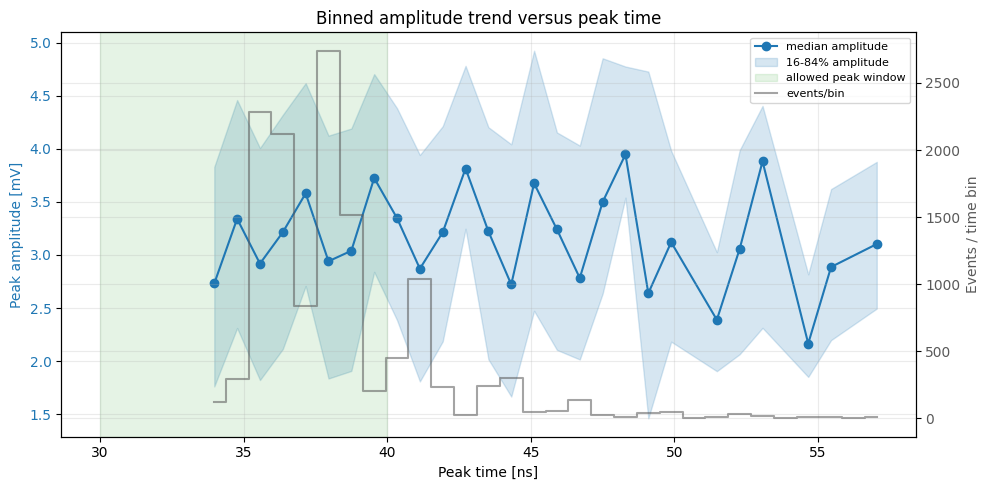

In [ ]:
trend_mask = finite_peak & real_peak_mask
x = peak_time[trend_mask]
y = peak_amplitude[trend_mask]

if len(x) < 20:
    print("Not enough real-peak events to build a binned trend plot.")
else:
    q_low, q_high = np.quantile(x, [0.01, 0.99])
    time_bins = np.linspace(q_low, q_high, 31)
    bin_centers = 0.5 * (time_bins[:-1] + time_bins[1:])
    bin_index = np.digitize(x, time_bins) - 1

    counts = np.zeros(len(bin_centers), dtype=int)
    med = np.full(len(bin_centers), np.nan)
    q16 = np.full(len(bin_centers), np.nan)
    q84 = np.full(len(bin_centers), np.nan)

    for i in range(len(bin_centers)):
        values = y[bin_index == i]
        counts[i] = len(values)
        if len(values) >= 5:
            q16[i], med[i], q84[i] = np.quantile(values, [0.16, 0.50, 0.84])

    valid = np.isfinite(med)

    fig, ax_amp = plt.subplots(figsize=(10, 5))
    ax_count = ax_amp.twinx()

    ax_amp.plot(bin_centers[valid], med[valid], "o-", color="tab:blue", label="median amplitude")
    ax_amp.fill_between(bin_centers[valid], q16[valid], q84[valid], color="tab:blue", alpha=0.18, label="16-84% amplitude")
    ax_amp.axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.12, label="allowed peak window")
    ax_amp.set_xlabel("Peak time [ns]")
    ax_amp.set_ylabel("Peak amplitude [mV]", color="tab:blue")
    ax_amp.tick_params(axis="y", labelcolor="tab:blue")

    ax_count.step(bin_centers, counts, where="mid", color="0.35", alpha=0.55, label="events/bin")
    ax_count.set_ylabel("Events / time bin", color="0.35")
    ax_count.tick_params(axis="y", labelcolor="0.35")

    lines1, labels1 = ax_amp.get_legend_handles_labels()
    lines2, labels2 = ax_count.get_legend_handles_labels()
    ax_amp.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=8)
    ax_amp.set_title("Binned amplitude trend versus peak time")
    fig.tight_layout()


## Impact of the selection on the mean waveform

Compare full-dataset average waveforms computed with different masks. This uses `summarize_waveforms(..., selection_mask=...)`, so the average is not limited to the small waveform sample loaded for display.


Mean waveform inputs
sample                                   events     fraction     t_min [ns]     V_min [mV]
----------------------------------------------------------------------------------------
all events                              316,820    100.000%          49.44        -0.1522
real peaks                               13,094      4.133%          38.13          -2.42
real peaks in allowed window             10,251      3.236%          37.76          -2.83
final selection                         313,977     99.103%          49.44        -0.1424


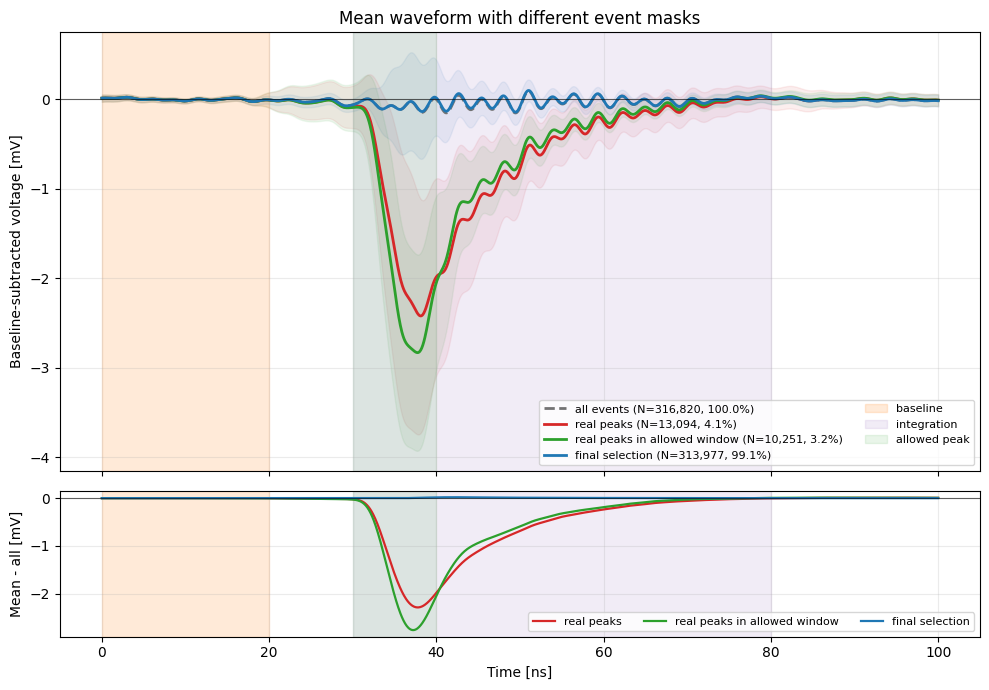

In [ ]:
def summarize_for_mean(label, mask, color, linestyle="-"):
    n_selected = int(np.sum(mask)) if mask is not None else summary_all["n_events"]
    if n_selected == 0:
        return None
    if mask is None:
        s = summary_all
    elif label == "real peaks" and summary_real_peak is not None:
        s = summary_real_peak
    else:
        s = summarize_waveforms(
            files,
            baseline_window_ns=baseline_window_ns,
            chunk_size=4096,
            selection_mask=mask,
        )
    return {
        "label": label,
        "summary": s,
        "color": color,
        "linestyle": linestyle,
        "n": s["n_events"],
        "fraction": s["n_events"] / summary_all["n_events"] if summary_all["n_events"] else np.nan,
    }

mean_waveform_sets = [
    summarize_for_mean("all events", None, "0.45", "--"),
    summarize_for_mean("real peaks", real_peak_mask, "tab:red", "-"),
    summarize_for_mean("real peaks in allowed window", real_in_time_mask, "tab:green", "-"),
    summarize_for_mean("final selection", keep_mask, "tab:blue", "-"),
]
mean_waveform_sets = [item for item in mean_waveform_sets if item is not None]

print("Mean waveform inputs")
print("=" * 88)
print(f"{'sample':<34} {'events':>12} {'fraction':>12} {'t_min [ns]':>14} {'V_min [mV]':>14}")
print("-" * 88)
for item in mean_waveform_sets:
    s = item["summary"]
    mean = s["mean_waveform_mV"]
    idx = int(np.argmin(mean))
    print(
        f"{item['label']:<34} {item['n']:>12,} {item['fraction']:>11.3%} "
        f"{s['time_ns'][idx]:>14.4g} {mean[idx]:>14.4g}"
    )
print("=" * 88)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax, ax_diff = axes

reference = summary_all["mean_waveform_mV"]
for item in mean_waveform_sets:
    s = item["summary"]
    t = s["time_ns"]
    mean = s["mean_waveform_mV"]
    rms = s["std_waveform_mV"]
    label = f"{item['label']} (N={item['n']:,}, {item['fraction']:.1%})"
    ax.plot(t, mean, color=item["color"], lw=2, ls=item["linestyle"], label=label)
    if item["label"] != "all events":
        ax.fill_between(t, mean - rms, mean + rms, color=item["color"], alpha=0.08)
        ax_diff.plot(t, mean - reference, color=item["color"], lw=1.6, label=item["label"])

for this_ax in axes:
    this_ax.axvspan(*baseline_window_ns, color="tab:orange", alpha=0.16, label="baseline" if this_ax is ax else None)
    this_ax.axvspan(*integration_window_ns, color="tab:purple", alpha=0.12, label="integration" if this_ax is ax else None)
    this_ax.axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.10, label="allowed peak" if this_ax is ax else None)
    this_ax.axhline(0, color="black", lw=0.8, alpha=0.6)

ax.set_ylabel("Baseline-subtracted voltage [mV]")
ax.set_title("Mean waveform with different event masks")
ax.legend(loc="best", fontsize=8, ncol=2)

ax_diff.set_xlabel("Time [ns]")
ax_diff.set_ylabel("Mean - all [mV]")
ax_diff.legend(loc="best", fontsize=8, ncol=3)
fig.tight_layout()


# Charge

## Best integration window selection

not really used for now

In [ ]:
candidate_windows_ns = [
    integration_window_ns
]

charges_by_window = compute_charges_for_windows(
    files,
    baseline_window_ns=baseline_window_ns,
    integration_windows_ns=candidate_windows_ns,
    selection_mask=None,
    chunk_size=4096,
)

print("Original-data candidate fixed-window charges")
print("window [ns]      q0.1%      q1%       q50%      q90%      q99%    q99.9%   [mV ns]")
for window, charge_values in charges_by_window.items():
    q = np.quantile(charge_values, [0.001, 0.01, 0.5, 0.90, 0.99, 0.999])
    print(
        f"{window[0]:4.0f}-{window[1]:<4.0f}"
        f" {q[0]:10.3f} {q[1]:9.3f} {q[2]:9.3f} {q[3]:9.3f} {q[4]:9.3f} {q[5]:9.3f}"
    )

Original-data candidate fixed-window charges
window [ns]      q0.1%      q1%       q50%      q90%      q99%    q99.9%   [mV ns]
  30-80       -7.418    -5.195     0.405     3.908    40.271    57.690


In [ ]:
charge_all_mV_ns = charges_by_window[integration_window_ns]

print(f"Selected integration window: {integration_window_ns[0]:.1f}-{integration_window_ns[1]:.1f} ns")
print("Original-data charge quantiles [mV ns]:")
for prob, value in zip(
    [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999],
    np.quantile(charge_all_mV_ns, [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999]),
):
    print(f"  q{prob:0.3f}: {value:9.4f}")

Selected integration window: 30.0-80.0 ns
Original-data charge quantiles [mV ns]:
  q0.001:   -7.4180
  q0.010:   -5.1948
  q0.100:   -2.6557
  q0.500:    0.4052
  q0.900:    3.9081
  q0.990:   40.2714
  q0.999:   57.6898


## Compute Charge

In [ ]:
selected_charges_by_window = compute_charges_for_windows(
    files,
    baseline_window_ns=baseline_window_ns,
    integration_windows_ns=[integration_window_ns],
    selection_mask=selection["keep_mask"],
    chunk_size=4096,
)
charge_selected_mV_ns = selected_charges_by_window[integration_window_ns]

print(f"Selected events: {selection['n_kept']} / {selection['n_total']} ({selection['efficiency']:.3%})")
print("Selected-data charge quantiles [mV ns]:")
if len(charge_selected_mV_ns):
    for prob, value in zip(
        [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999],
        np.quantile(charge_selected_mV_ns, [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999]),
    ):
        print(f"  q{prob:0.3f}: {value:9.4f}")
else:
    print("  no events kept")

Selected events: 313977 / 316820 (99.103%)
Selected-data charge quantiles [mV ns]:
  q0.001:   -7.4217
  q0.010:   -5.2031
  q0.100:   -2.6674
  q0.500:    0.3779
  q0.900:    3.7467
  q0.990:   38.0521
  q0.999:   56.2674


Approximate peak positions [ns]: [33.25456728 41.25342419 49.2522811  52.751781   57.75106656 60.7506379
 66.24985203 69.24942337]
Approximate spacings [ns]: [7.99885691 7.99885691 3.4994999  4.99928557 2.99957134 5.49921412
 2.99957134]


/var/folders/80/x5l9nnmd2gb3szz23pnjrgpm0000gn/T/ipykernel_67085/2413589452.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


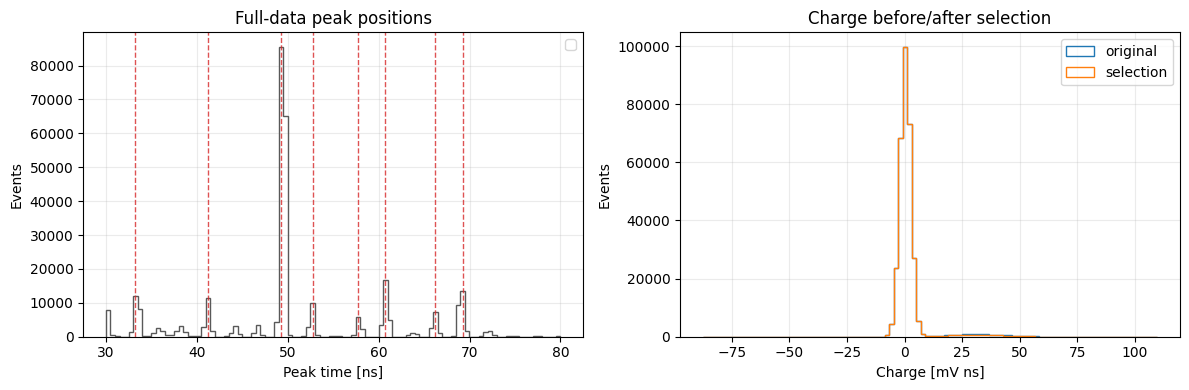

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Peak-time histogram
counts, edges, _ = axes[0].hist(
    selection["peak_time_ns"],
    # bins=25,
    bins=100,
    histtype="step",
    color="0.35",
)

centers = 0.5 * (edges[:-1] + edges[1:])

# Approximate peak finding, no fit
from scipy.signal import find_peaks

peaks, props = find_peaks(
    counts,
    prominence=0.05 * np.max(counts),
    distance=5,
)

peak_times = centers[peaks]
peak_heights = counts[peaks]

# Sort peaks by height, keep the most relevant few, then order by time
n_show = 12 #min(4, len(peak_times))
idx = np.argsort(peak_heights)[-n_show:]
peak_times_main = np.sort(peak_times[idx])

# Draw peak markers
for t in peak_times_main:
    axes[0].axvline(t, color="tab:red", ls="--", lw=1, alpha=0.8)

# Estimate separations between neighboring peaks
if len(peak_times_main) >= 2:
    dt_peaks = np.diff(peak_times_main)

    txt = "Peak spacing:\n" + "\n".join(
        f"{dt:.2f} ns" for dt in dt_peaks
    )

    print("Approximate peak positions [ns]:", peak_times_main)
    print("Approximate spacings [ns]:", dt_peaks)
else:
    print("Not enough peaks found to estimate spacing.")

# axes[0].axvspan( *allowed_peak_window_ns, color="tab:green", alpha=0.18, label="allowed peak window")
axes[0].set_xlabel("Peak time [ns]")
axes[0].set_ylabel("Events")
axes[0].set_title("Full-data peak positions")
axes[0].legend()

axes[1].hist(charge_all_mV_ns, bins=100, range=None, histtype="step", label="original")
axes[1].hist(charge_selected_mV_ns, bins=100, range=None, histtype="step", label="selection")
axes[1].set_xlabel("Charge [mV ns]")
axes[1].set_ylabel("Events")
axes[1].set_title("Charge before/after selection")
# axes[1].set_yscale("log")
axes[1].legend()
fig.tight_layout()

## Peak-aligned waveform comparison

Check whether the dominant peak-time group is genuinely shape-different, or whether the apparent difference mostly comes from averaging waveforms that are not aligned in time.


Dominant peak-time class
Dominant center: 38.12 ns
Dominant window: 37.37 to 38.87 ns
Histogram bin width used for finding peak: 0.4164 ns
Dominant real-peak events                         4,220 / 316,820    (  1.332%)
Other real-peak events                            8,874 / 316,820    (  2.801%)
Interpretation guide:
- If the aligned difference becomes small, the earlier difference was mostly timing/alignment.
- If the aligned difference remains around the peak or tail, the dominant class has a different pulse shape or amplitude.


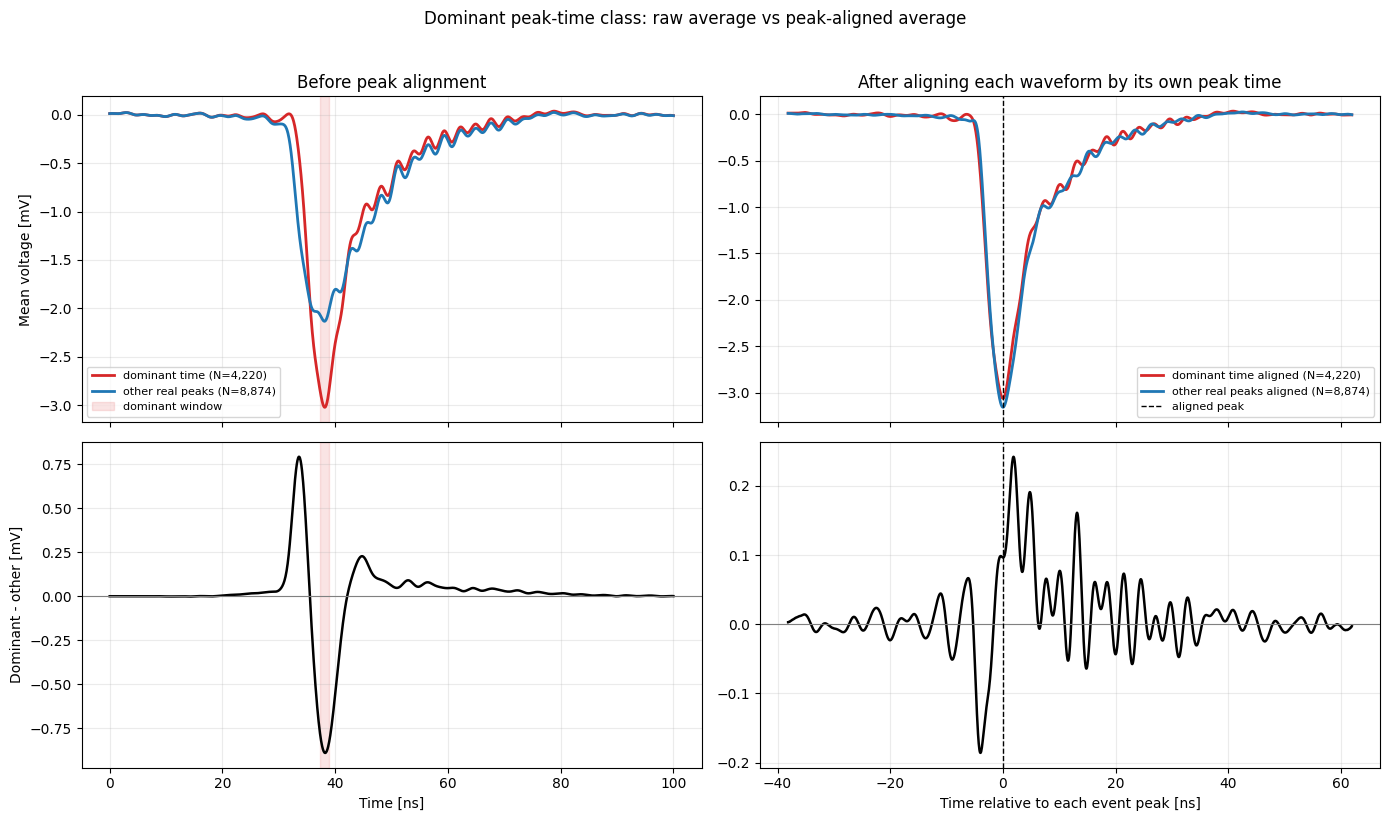

In [ ]:
def dominant_peak_time_window(peak_time_ns, mask, bins=120, half_width_ns=None):
    values = np.asarray(peak_time_ns, dtype=float)
    selected = mask & np.isfinite(values)
    if np.sum(selected) == 0:
        raise ValueError("No finite peak times in the selected mask")
    counts, edges = np.histogram(values[selected], bins=bins)
    i_max = int(np.argmax(counts))
    center = 0.5 * (edges[i_max] + edges[i_max + 1])
    bin_width = edges[i_max + 1] - edges[i_max]
    if half_width_ns is None:
        half_width_ns = max(0.75, 1.5 * bin_width)
    return center, (center - half_width_ns, center + half_width_ns), counts[i_max], bin_width


def average_peak_aligned_waveforms(
    files,
    event_mask,
    peak_time_ns,
    baseline_window_ns,
    relative_time_ns=None,
    channel="Channel 1",
    chunk_size=4096,
):
    event_mask = np.asarray(event_mask, dtype=bool)
    peak_time_ns = np.asarray(peak_time_ns, dtype=float)
    offset = 0
    sum_waveform = None
    sumsq_waveform = None
    count_waveform = None
    n_events = 0
    reference_time_ns = None

    for chunk in iter_keysight_chunks(files, channel=channel, chunk_size=chunk_size):
        time_ns_chunk = chunk["time_ns"]
        n_chunk = chunk["voltage_mV"].shape[0]
        chunk_mask = event_mask[offset: offset + n_chunk]
        chunk_peak_time = peak_time_ns[offset: offset + n_chunk]
        offset += n_chunk

        chunk_mask = chunk_mask & np.isfinite(chunk_peak_time)
        if not np.any(chunk_mask):
            continue

        voltage_bs_mV, _ = subtract_baseline(
            time_ns_chunk,
            chunk["voltage_mV"],
            baseline_window_ns=baseline_window_ns,
        )
        voltage_bs_mV = voltage_bs_mV[chunk_mask]
        chunk_peak_time = chunk_peak_time[chunk_mask]

        if relative_time_ns is None and reference_time_ns is None:
            reference_time_ns = time_ns_chunk
            relative_time_ns = time_ns_chunk - np.median(chunk_peak_time)
        elif reference_time_ns is None:
            reference_time_ns = time_ns_chunk

        if sum_waveform is None:
            sum_waveform = np.zeros_like(relative_time_ns, dtype=float)
            sumsq_waveform = np.zeros_like(relative_time_ns, dtype=float)
            count_waveform = np.zeros_like(relative_time_ns, dtype=int)

        for waveform, t_peak in zip(voltage_bs_mV, chunk_peak_time):
            aligned = np.interp(relative_time_ns + t_peak, time_ns_chunk, waveform, left=np.nan, right=np.nan)
            finite = np.isfinite(aligned)
            sum_waveform[finite] += aligned[finite]
            sumsq_waveform[finite] += aligned[finite] ** 2
            count_waveform[finite] += 1
            n_events += 1

    if n_events == 0:
        raise ValueError("No events selected for aligned waveform average")

    mean = np.full_like(sum_waveform, np.nan, dtype=float)
    std = np.full_like(sum_waveform, np.nan, dtype=float)
    valid = count_waveform > 0
    mean[valid] = sum_waveform[valid] / count_waveform[valid]
    variance = np.zeros_like(sum_waveform, dtype=float)
    variance[valid] = sumsq_waveform[valid] / count_waveform[valid] - mean[valid] ** 2
    std[valid] = np.sqrt(np.maximum(variance[valid], 0.0))

    return {
        "relative_time_ns": relative_time_ns,
        "mean_waveform_mV": mean,
        "std_waveform_mV": std,
        "count_per_sample": count_waveform,
        "n_events": n_events,
    }

# Identify the dominant real-peak timing class automatically.
dominant_center_ns, dominant_window_ns, dominant_bin_count, dominant_bin_width_ns = dominant_peak_time_window(
    selection["peak_time_ns"],
    real_peak_mask,
    bins=120,
    half_width_ns=None,
)

dominant_time_mask = (
    real_peak_mask
    & (selection["peak_time_ns"] >= dominant_window_ns[0])
    & (selection["peak_time_ns"] <= dominant_window_ns[1])
)
other_real_time_mask = real_peak_mask & ~dominant_time_mask

print("Dominant peak-time class")
print("=" * 88)
print(f"Dominant center: {dominant_center_ns:.4g} ns")
print(f"Dominant window: {dominant_window_ns[0]:.4g} to {dominant_window_ns[1]:.4g} ns")
print(f"Histogram bin width used for finding peak: {dominant_bin_width_ns:.4g} ns")
print_count_row("Dominant real-peak events", int(np.sum(dominant_time_mask)), selection["n_total"])
print_count_row("Other real-peak events", int(np.sum(other_real_time_mask)), selection["n_total"])
print("=" * 88)

# Unaligned means: useful because it shows the original timing-class difference.
summary_dominant_unaligned = summarize_waveforms(
    files,
    baseline_window_ns=baseline_window_ns,
    selection_mask=dominant_time_mask,
    chunk_size=4096,
)
summary_other_unaligned = summarize_waveforms(
    files,
    baseline_window_ns=baseline_window_ns,
    selection_mask=other_real_time_mask,
    chunk_size=4096,
)

# Aligned means: each waveform is shifted so its own peak time is at relative time 0.
relative_time_ns = summary_all["time_ns"] - dominant_center_ns
summary_dominant_aligned = average_peak_aligned_waveforms(
    files,
    dominant_time_mask,
    selection["peak_time_ns"],
    baseline_window_ns=baseline_window_ns,
    relative_time_ns=relative_time_ns,
    chunk_size=4096,
)
summary_other_aligned = average_peak_aligned_waveforms(
    files,
    other_real_time_mask,
    selection["peak_time_ns"],
    baseline_window_ns=baseline_window_ns,
    relative_time_ns=relative_time_ns,
    chunk_size=4096,
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex="col")

# Unaligned comparison.
axes[0, 0].plot(
    summary_dominant_unaligned["time_ns"],
    summary_dominant_unaligned["mean_waveform_mV"],
    color="tab:red",
    lw=2,
    label=f"dominant time (N={summary_dominant_unaligned['n_events']:,})",
)
axes[0, 0].plot(
    summary_other_unaligned["time_ns"],
    summary_other_unaligned["mean_waveform_mV"],
    color="tab:blue",
    lw=2,
    label=f"other real peaks (N={summary_other_unaligned['n_events']:,})",
)
axes[0, 0].axvspan(*dominant_window_ns, color="tab:red", alpha=0.12, label="dominant window")
axes[0, 0].set_title("Before peak alignment")
axes[0, 0].set_ylabel("Mean voltage [mV]")
axes[0, 0].legend(fontsize=8)

unaligned_diff = summary_dominant_unaligned["mean_waveform_mV"] - summary_other_unaligned["mean_waveform_mV"]
axes[1, 0].plot(summary_dominant_unaligned["time_ns"], unaligned_diff, color="black", lw=1.8)
axes[1, 0].axhline(0, color="0.5", lw=0.8)
axes[1, 0].axvspan(*dominant_window_ns, color="tab:red", alpha=0.12)
axes[1, 0].set_xlabel("Time [ns]")
axes[1, 0].set_ylabel("Dominant - other [mV]")

# Peak-aligned comparison.
axes[0, 1].plot(
    summary_dominant_aligned["relative_time_ns"],
    summary_dominant_aligned["mean_waveform_mV"],
    color="tab:red",
    lw=2,
    label=f"dominant time aligned (N={summary_dominant_aligned['n_events']:,})",
)
axes[0, 1].plot(
    summary_other_aligned["relative_time_ns"],
    summary_other_aligned["mean_waveform_mV"],
    color="tab:blue",
    lw=2,
    label=f"other real peaks aligned (N={summary_other_aligned['n_events']:,})",
)
axes[0, 1].axvline(0, color="black", ls="--", lw=1, label="aligned peak")
axes[0, 1].set_title("After aligning each waveform by its own peak time")
axes[0, 1].legend(fontsize=8)

aligned_diff = summary_dominant_aligned["mean_waveform_mV"] - summary_other_aligned["mean_waveform_mV"]
axes[1, 1].plot(summary_dominant_aligned["relative_time_ns"], aligned_diff, color="black", lw=1.8)
axes[1, 1].axhline(0, color="0.5", lw=0.8)
axes[1, 1].axvline(0, color="black", ls="--", lw=1)
axes[1, 1].set_xlabel("Time relative to each event peak [ns]")

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)

fig.suptitle("Dominant peak-time class: raw average vs peak-aligned average", y=1.02)
fig.tight_layout()

print("Interpretation guide:")
print("- If the aligned difference becomes small, the earlier difference was mostly timing/alignment.")
print("- If the aligned difference remains around the peak or tail, the dominant class has a different pulse shape or amplitude.")


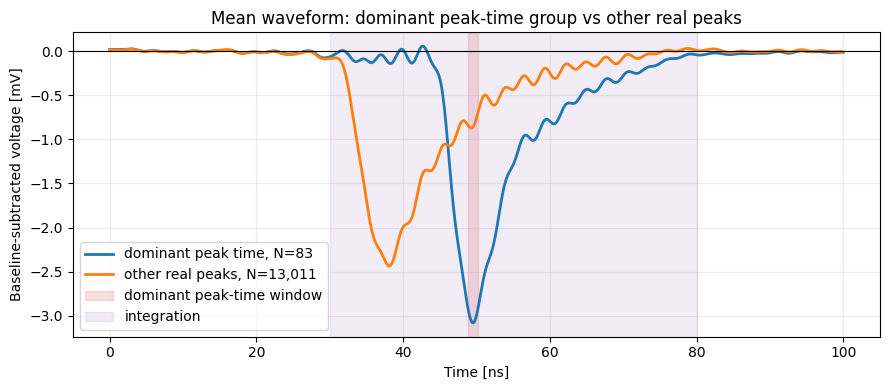

In [ ]:
dominant_peak_time_ns = 49.5
dominant_window_ns = (48.8, 50.2)

dominant_mask = (
    real_peak_mask
    & (selection["peak_time_ns"] >= dominant_window_ns[0])
    & (selection["peak_time_ns"] <= dominant_window_ns[1])
)

other_real_peak_mask = real_peak_mask & ~dominant_mask

summary_dominant = summarize_waveforms(
    files,
    baseline_window_ns=baseline_window_ns,
    selection_mask=dominant_mask,
    chunk_size=4096,
)

summary_other = summarize_waveforms(
    files,
    baseline_window_ns=baseline_window_ns,
    selection_mask=other_real_peak_mask,
    chunk_size=4096,
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    summary_dominant["time_ns"],
    summary_dominant["mean_waveform_mV"],
    lw=2,
    label=f"dominant peak time, N={summary_dominant['n_events']:,}",
)

ax.plot(
    summary_other["time_ns"],
    summary_other["mean_waveform_mV"],
    lw=2,
    label=f"other real peaks, N={summary_other['n_events']:,}",
)

ax.axvspan(*dominant_window_ns, color="tab:red", alpha=0.15, label="dominant peak-time window")
ax.axvspan(*integration_window_ns, color="tab:purple", alpha=0.12, label="integration")
ax.axhline(0, color="black", lw=0.8)

ax.set_xlabel("Time [ns]")
ax.set_ylabel("Baseline-subtracted voltage [mV]")
ax.set_title("Mean waveform: dominant peak-time group vs other real peaks")
ax.legend()
fig.tight_layout()

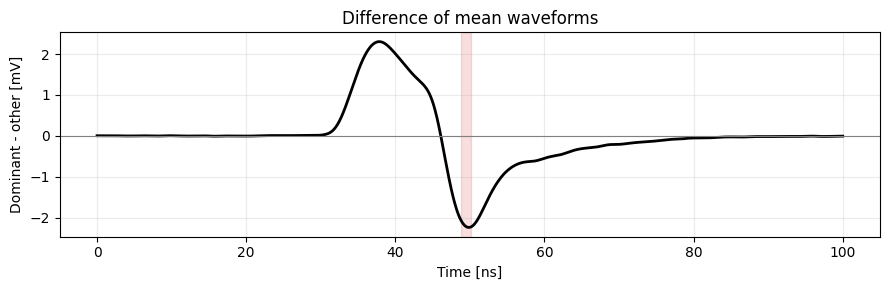

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3))

diff = summary_dominant["mean_waveform_mV"] - summary_other["mean_waveform_mV"]

ax.plot(summary_dominant["time_ns"], diff, color="black", lw=2)
ax.axhline(0, color="0.5", lw=0.8)
ax.axvspan(*dominant_window_ns, color="tab:red", alpha=0.15)
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Dominant - other [mV]")
ax.set_title("Difference of mean waveforms")
fig.tight_layout()

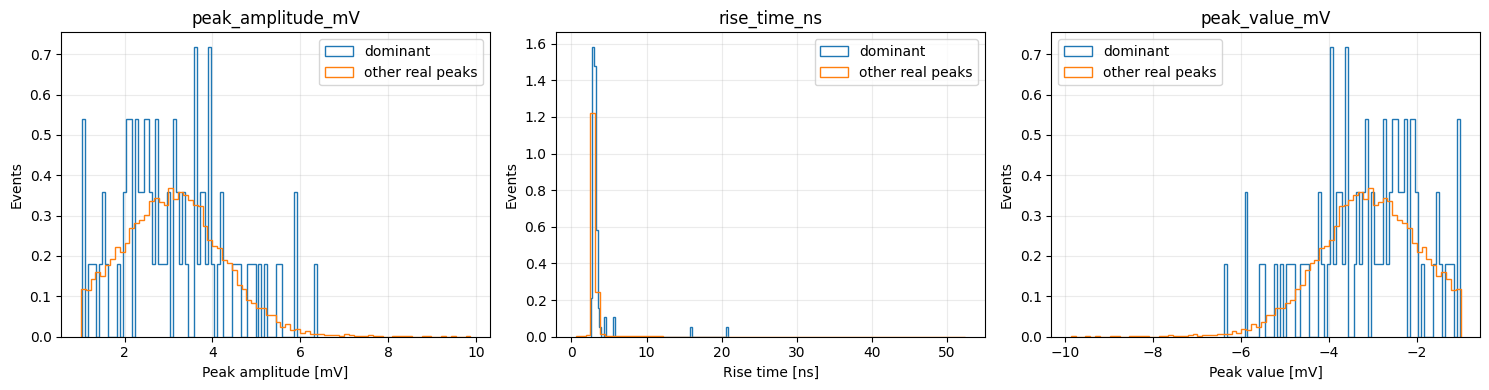

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
den = True
for ax, name, xlabel in [
    (axes[0], "peak_amplitude_mV", "Peak amplitude [mV]"),
    (axes[1], "rise_time_ns", "Rise time [ns]"),
    (axes[2], "peak_value_mV", "Peak value [mV]"),
]:
    ax.hist(selection[name][dominant_mask], bins=80, histtype="step", label="dominant", density=den)
    ax.hist(selection[name][other_real_peak_mask], bins=80, histtype="step", label="other real peaks", density=den)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Events")
    ax.set_title(name)
    ax.legend()

fig.tight_layout()

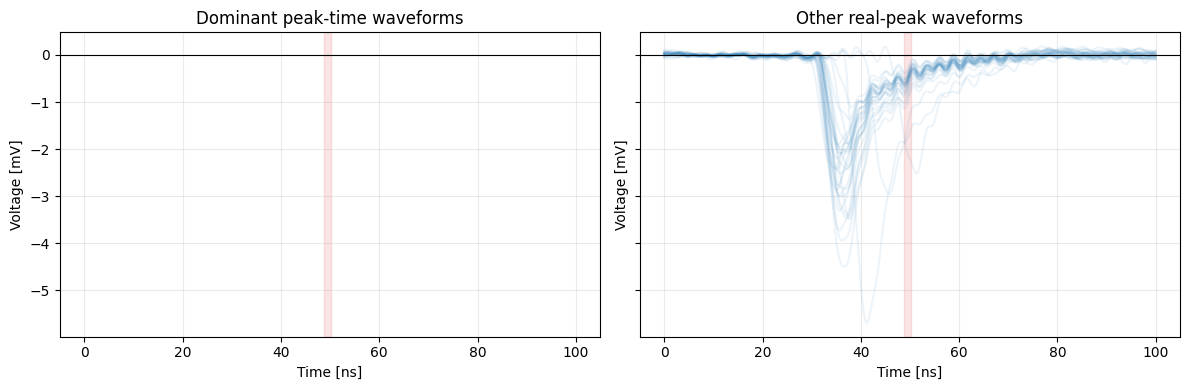

In [ ]:
sample_dom = np.flatnonzero(dominant_mask[:len(voltage_sample_bs_mV)])
sample_other = np.flatnonzero(other_real_peak_mask[:len(voltage_sample_bs_mV)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for idx in sample_dom[:200]:
    axes[0].plot(time_ns, voltage_sample_bs_mV[idx], color="tab:red", alpha=0.08) #, lw=0.8

for idx in sample_other[:200]:
    axes[1].plot(time_ns, voltage_sample_bs_mV[idx], color="tab:blue", alpha=0.08) #, lw=0.8

axes[0].set_title("Dominant peak-time waveforms")
axes[1].set_title("Other real-peak waveforms")

for ax in axes:
    ax.axvspan(*dominant_window_ns, color="tab:red", alpha=0.12)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Voltage [mV]")

fig.tight_layout()